# Анализ рынка ритейла РФ (2737 компаний)
## **Источник:** [Kaggle Russian Retail](https://www.kaggle.com/datasets/pavelkunitsyn/russian-retail)
## **Цель:** Найти растущие сегменты и лидеров расширения для инвесторов
## **Стек:** Python, pandas, matplotlib, регулярные выражения


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("russian_retail.csv")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Задание 1
## Цель: Понять данные и найти инсайты для отчёта.
## Ожидаемый вывод: Сколько магазинов в среднем по РФ? Какие домены лидируют?

In [7]:
print(df.info()) # типы данных, пропуски

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2737 entries, 0 to 2736
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               2729 non-null   object 
 1   contry_origin      2709 non-null   object 
 2   domain             2729 non-null   object 
 3   price_category     2737 non-null   object 
 4   founded            2533 non-null   float64
 5   presence_world     1161 non-null   float64
 6   presence_russia    2693 non-null   object 
 7   presence_regions   2675 non-null   object 
 8   description        2727 non-null   object 
 9   plans              760 non-null    float64
 10  total_rented_area  117 non-null    float64
dtypes: float64(4), object(7)
memory usage: 235.3+ KB
None


In [8]:
print(df.describe()) # статистика по числам

           founded  presence_world         plans  total_rented_area
count  2533.000000     1161.000000    760.000000       1.170000e+02
mean   1997.679826      502.593454     66.563158       9.841169e+04
std      27.122166     3538.428214    468.676716       3.876114e+05
min    1300.000000        1.000000      1.000000       1.400000e+01
25%    1995.000000        7.000000      4.000000       2.100000e+03
50%    2002.000000       21.000000     10.000000       1.200000e+04
75%    2010.000000       94.000000     20.000000       3.000000e+04
max    2020.000000    60000.000000  10000.000000       3.800000e+06


In [9]:
top_domains = df['domain'].value_counts().head(10)
print(top_domains)

domain
Одежда                       387
Кафе, ресторан               343
Продукты питания             274
Товары и услуги для детей    128
Все для дома                 106
Обувь                        102
Красота                      101
Мебель                        97
Спорт                         90
Ремонт и строительство        88
Name: count, dtype: int64


## 📊 График 1: Топ-10 доменов по количеству компаний

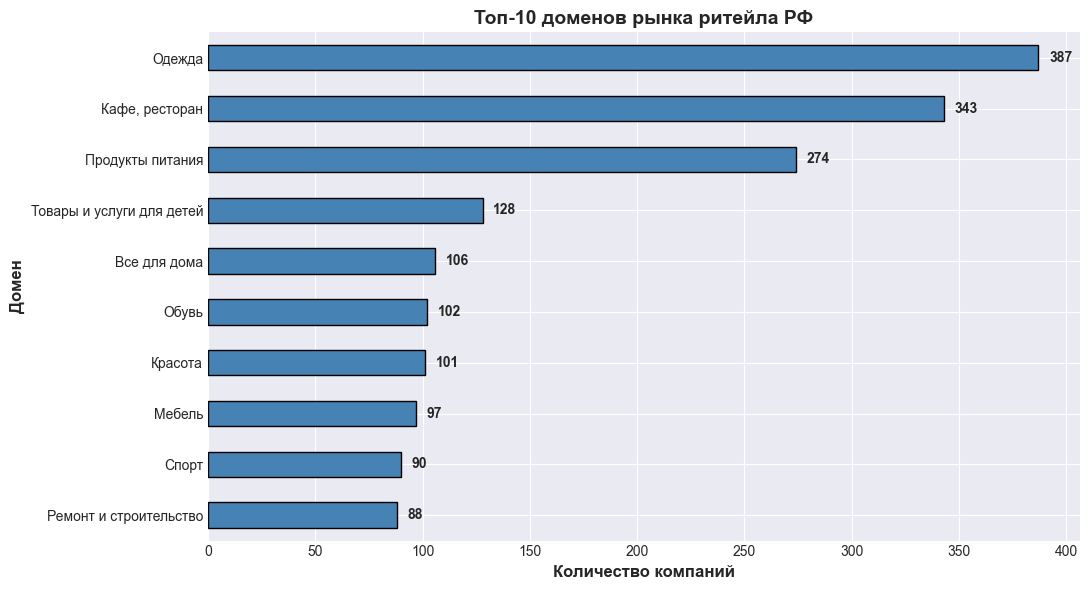

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
top_domains.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Количество компаний', fontsize=12, fontweight='bold')
ax.set_ylabel('Домен', fontsize=12, fontweight='bold')
ax.set_title('Топ-10 доменов рынка ритейла РФ', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_domains.values):
    ax.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
print(df['price_category'].value_counts()) # сегменты цен

price_category
Средний                                                           1805
Средний; Выше среднего                                             243
Выше среднего                                                      133
Люкс / Премиум                                                      98
Ниже среднего                                                       96
Ниже среднего; Средний                                              73
Дисконт                                                             60
Средний; Выше среднего; Люкс / Премиум                              53
Выше среднего; Люкс / Премиум                                       46
Дисконт; Ниже среднего                                              28
Дисконт; Ниже среднего; Средний                                     26
Ниже среднего; Средний; Выше среднего                               24
Неизвестно                                                          16
Дисконт; Ниже среднего; Средний; Выше среднего                

# Задание 2: Очистка данных "presence_russia"
## Проблема: Столбец содержит текст вроде "80 и 876 франчайзинговых" → нужно число.
## Задача: Построить график топ-10 ритейлеров по числу магазинов в РФ.

In [12]:
def extract_number(text):
    if pd.isna(text): return 0
    import re
    numbers = re.findall(r'\d+', str(text))
    return int(numbers[0]) if numbers else 0

df['stores_ru_clean'] = df['presence_russia'].apply(extract_number)
print(df['stores_ru_clean'].describe())

count     2737.000000
mean       146.150895
std       1828.935632
min          0.000000
25%          5.000000
50%         15.000000
75%         45.000000
max      60000.000000
Name: stores_ru_clean, dtype: float64


# Задание 3: Сегментация рынка

## Цель: Найти растущие сегменты для инвестиций.
## Вывод: "Одежда Средний сегмент = 150 магазинов в среднем".

In [13]:
segment_analysis = df.groupby(['domain', 'price_category']).agg({
    'stores_ru_clean': ['count', 'mean', 'sum']
}).round(2)
print(segment_analysis.sort_values(('stores_ru_clean', 'sum'), ascending=False))

                                                                        stores_ru_clean  \
                                                                                  count   
domain                   price_category                                                   
Банк, кредит, заем       Средний                                                     70   
Ставки и лотереи         Средний                                                      3   
Услуги населению         Дисконт; Ниже среднего; Средний; Выше среднего               1   
Продукты питания         Дисконт; Ниже среднего                                       7   
Одежда                   Средний                                                    188   
...                                                                                 ...   
Обувь                    Выше среднего; Люкс / Премиум                                1   
Авто и товары для авто   Выше среднего                                                1   

## 📈 График 2: Главные сегменты (домены × средний размер)

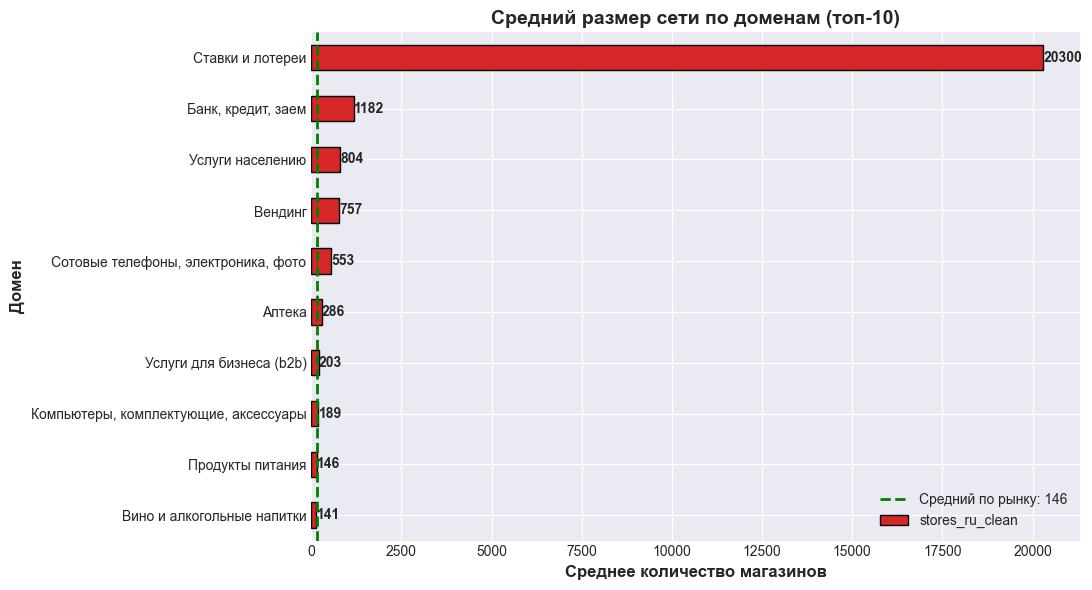

In [14]:
domain_avg = df.groupby('domain')['stores_ru_clean'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#d62728' if x > 100 else '#1f77b4' for x in domain_avg.values]
domain_avg.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Среднее количество магазинов', fontsize=12, fontweight='bold')
ax.set_ylabel('Домен', fontsize=12, fontweight='bold')
ax.set_title('Средний размер сети по доменам (топ-10)', fontsize=14, fontweight='bold')
ax.axvline(x=df['stores_ru_clean'].mean(), color='green', linestyle='--', linewidth=2, label=f'Средний по рынку: {df["stores_ru_clean"].mean():.0f}')
ax.legend()
ax.invert_yaxis()
for i, v in enumerate(domain_avg.values):
    ax.text(v + 10, i, f'{v:.0f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Задание 4: Топ-10 ритейлеров по количеству регионов присутствия в РФ
## Бизнес-вопрос: Какие компании имеют самое широкое территориальное покрытие?

In [15]:
df['regions_count'] = df['presence_regions'].apply(lambda x: len(str(x).split(';')) if pd.notna(x) else 0)
top_regions = df.nlargest(10, 'regions_count')[['name', 'domain', 'regions_count', 'stores_ru_clean']]
print("Топ по географии:")
print(top_regions)

Топ по географии:
                    name                               domain  regions_count  \
1522      Золотая корона                   Банк, кредит, заем            271   
1775              Магнит                     Продукты питания            264   
150             Boxberry             Услуги для бизнеса (b2b)            243   
1552             ИНВИТРО      Здоровье, лечение, профилактика            238   
1461       Дочки Сыночки            Товары и услуги для детей            205   
1326           Восточный                   Банк, кредит, заем            202   
1021         Wildberries                               Одежда            195   
701               Optima               Парфюмерия и Косметика            187   
1200              Билайн  Сотовые телефоны, электроника, фото            185   
1829  Мебель тут дешевле                               Мебель            185   

      stores_ru_clean  
1522            40000  
1775            14063  
150              3500  
1552 

## 🗺️ График 3: Лидеры по масштабу и географии

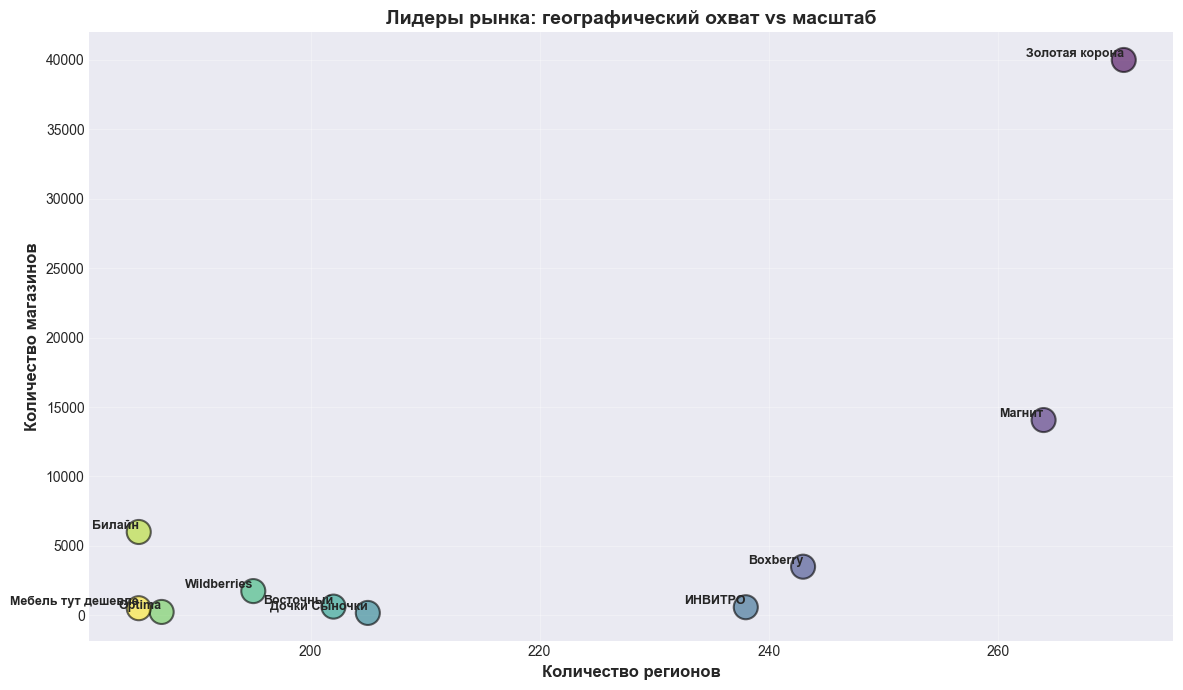

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
top_10_retailers = df.nlargest(10, 'regions_count')

scatter = ax.scatter(top_10_retailers['regions_count'], 
                     top_10_retailers['stores_ru_clean'],
                     s=300, alpha=0.6, c=range(10), cmap='viridis', edgecolors='black', linewidth=1.5)

for idx, row in top_10_retailers.iterrows():
    ax.annotate(row['name'], 
                (row['regions_count'], row['stores_ru_clean']),
                fontsize=9, ha='right', va='bottom', fontweight='bold')

ax.set_xlabel('Количество регионов', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество магазинов (логарифмическая шкала)', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество магазинов', fontsize=12, fontweight='bold')
ax.set_title('Лидеры рынка: географический охват vs масштаб', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Задание 5: Прогноз расширения
## Бизнес-вопрос: Какие компании растут быстрее всех относительно текущего размера?

In [17]:
df['growth_potential'] = df['plans'].fillna(0) / df['stores_ru_clean'].replace(0, 1)
fast_growers = df.nlargest(10, 'growth_potential')[['name', 'domain', 'growth_potential', 'stores_ru_clean', 'plans']]
print(fast_growers)

                                  name                           domain  \
53                           Altair VR                      Развлечения   
2525                            Фермер                 Продукты питания   
1068                           Авокадо                 Продукты питания   
2324                        Слетать.ру              Туризм, путешествия   
2612                         Циферблат                   Кафе, ресторан   
1077                         Автополка           Авто и товары для авто   
203                              Cilek        Товары и услуги для детей   
529                           LabQuest  Здоровье, лечение, профилактика   
1081  Агентство регионального развития         Услуги для бизнеса (b2b)   
1632                             Колба       Вино и алкогольные напитки   

      growth_potential  stores_ru_clean   plans  
53              1000.0                1  1000.0  
2525            1000.0                1  1000.0  
1068             500.0  

# 🎯 КРАТКИЙ ВЫВОД
## 1. **Банки (84k магазинов)** и **одежда (387 компаний)** — лидеры по текущему размеру рынка.
## 2. **Altair VR, Фермер** (1000x рост) — главные претенденты
## 3. **Золотая корона, Магнит, Boxberry** — лидеры по географическому охвату (83-85 регионов).
## 4. Регионы вне Москвы — зона роста с низкой конкуренцией.
